# Experimental Validation of the Supervisory Portfolio Governance Framework

This notebook provides a rigorous experimental validation of the **Supervisory Portfolio Governance Framework**, a deterministic portfolio management system designed to improve portfolio stability under market instability.

Traditional portfolio optimization approaches, particularly the classical **Mean–Variance (MV) framework**, are known to suffer from significant sensitivity to estimation errors. Small variations in estimated returns or covariance matrices can lead to highly concentrated portfolios and unstable allocations. This phenomenon is often referred to as the **estimation error problem** in portfolio optimization.

To address these limitations, the proposed framework introduces a governance-based architecture composed of three primary components:

### 1. Shrinkage Estimation Layer
Expected returns and covariance matrices are stabilized using robust statistical estimators:
- **James–Stein shrinkage** for expected returns
- **Ledoit–Wolf shrinkage** for covariance matrices

These methods reduce estimation noise and improve numerical stability in high-dimensional financial datasets.

### 2. Composite Instability Index
Market stress is quantified through a multi-factor instability indicator combining:

- Cross-sectional volatility
- Mean pairwise asset correlation
- Covariance matrix drift

Each component is standardized relative to a historical baseline to produce a composite instability score.

### 3. Deterministic Regime Operator
The framework introduces a deterministic governance rule:

- If instability exceeds a predefined threshold, the portfolio switches to **Equal Weight allocation**.
- Otherwise, the system applies **Shrinkage-based Mean–Variance optimization**.

This mechanism prioritizes capital preservation during periods of systemic instability.

---

## Experimental Objectives

The purpose of this notebook is to scientifically validate the framework across several dimensions:

1. **Portfolio performance relative to standard benchmarks**
2. **Risk reduction and drawdown protection**
3. **Robustness across multiple asset universes**
4. **Behaviour during market stress periods**
5. **Statistical significance of observed improvements**

All experiments follow a strict **out-of-sample evaluation protocol**, ensuring that model parameters are estimated using historical training data and evaluated on unseen test periods.

The following sections will systematically evaluate each component of the framework.

In [59]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while not (p / "agents").exists() and p != p.parent:
    p = p.parent

sys.path.insert(0, str(p))

In [60]:
# Core scientific libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Financial data
import yfinance as yf

# Project agents
from agents.data_alignment_agent import DataAlignmentAgent
from agents.shrinkage_agent import ShrinkageAgent
from agents.instability_agent import InstabilityAgent
from agents.regime_agent import RegimeAgent
from agents.optimization_agent import OptimizationAgent
from agents.performance_evaluator import PerformanceEvaluator

print("Environment loaded successfully.")

Environment loaded successfully.


# Asset Universe Definition
A critical requirement in portfolio research is ensuring that the evaluation of a strategy is not limited to a small or biased set of assets. Many portfolio optimization techniques appear effective when tested on a small group of securities but fail to generalize across broader markets.
To ensure the robustness of the proposed **Supervisory Portfolio Governance Framework**, this study evaluates the system across multiple **asset universes representing different geographic markets and sector compositions**.
Each universe contains **20 highly liquid large-cap securities**, ensuring that the covariance estimation process is meaningful and that the resulting portfolios reflect realistic market conditions.
The following universes are used in this study:
### 1. US Technology Universe
A collection of leading technology companies representing the global innovation sector. These stocks are known for high growth and strong correlation structures.
### 2. US Diversified Universe
Companies across multiple economic sectors including finance, healthcare, energy, industrials, and consumer goods. This universe tests how the framework behaves in diversified economic environments.
### 3. European Large-Cap Universe
Major European corporations from multiple countries. This allows evaluation of the framework across different regulatory environments and economic conditions.
### 4. Asian Market Universe
Leading companies from Asia, including both developed and emerging markets. This tests geographic generalization of the model.
### 5. Global ETF Universe
A set of diversified exchange-traded funds representing broad market exposures. This universe allows evaluation using index-level investment instruments.
Each universe will be processed independently through the full pipeline:
Data Acquisition → Data Alignment → Shrinkage Estimation → Instability Detection → Regime Selection → Portfolio Optimization → Performance Evaluation.

In [61]:
# Define asset universes (20 assets each)


# ── Five universes ───────────────────────────────────────────
UNIVERSES = {

    "U1_US_LargeCap": {
        "label": "US Large-Cap Equities",
        "region": "United States",
        "asset_type": "Individual Stocks",
        "start": "2010-01-01",
        "tickers": [
            "AAPL","MSFT","GOOGL","AMZN",      # Technology
            "JPM","BAC","GS","MS",             # Financial
            "XOM","CVX","COP",                 # Energy
            "JNJ","PFE","UNH",                 # Healthcare
            "PG","KO","PEP",                   # Consumer Staples
            "CAT","BA",                        # Industrial
        ],
    },

    "U2_European_ETFs": {
        "label": "European Country ETFs",
        "region": "Europe",
        "asset_type": "iShares MSCI Country ETF",
        "start": "2010-01-01",
        # EDEN replaced by ENOR (Norway); EWC replaced by EPOL (Poland)
        "tickers": [
            "EWG","EWU","EWQ","EWI",           # DE, UK, FR, IT
            "EWP","EWN","EWD","EWL",           # ES, NL, SE, CH
            "EWK","EWO","ENOR","EPOL",         # BE, AT, NO, PL
        ],
    },

    "U3_AsiaPacific_ETFs": {
        "label": "Asia-Pacific Country ETFs",
        "region": "Asia-Pacific",
        "asset_type": "iShares MSCI Country ETF",
        "start": "2012-01-01",   # INDA available from Feb 2012
        # EWZ (Brazil) replaced by AAXJ (Asia ex-Japan)
        "tickers": [
            "EWJ","EWH","EWA","EWY",           # JP, HK, AU, KR
            "EWT","INDA","FXI","EWM",          # TW, IN, CN, MY
            "EWS","AAXJ",                      # SG, Asia ex-JP
        ],
    },

    "U4_US_Sectors": {
        "label": "US Sector ETFs (SPDR)",
        "region": "United States",
        "asset_type": "SPDR Select Sector ETF",
        "start": "2010-01-01",
        # XLRE (2015) and XLC (2018) excluded — insufficient history
        "tickers": [
            "XLK","XLF","XLE","XLV",           # Tech, Financial, Energy, Health
            "XLP","XLY","XLI","XLB","XLU",     # Staples, Discr, Indus, Mat, Util
        ],
    },

    "U5_MultiAsset": {
        "label": "Multi-Asset Class ETFs",
        "region": "Global",
        "asset_type": "Multi-Asset ETF",
        "start": "2010-01-01",
        "tickers": [
            "SPY","EFA","EEM",                 # Equity: US, Intl, EM
            "AGG","IEF","TIP","HYG",           # Bonds: Agg, Treasury, TIPS, HY
            "GLD","VNQ","GSG",                 # Real Assets: Gold, REIT, Cmdty
        ],
    },
}


# Print summary
for universe, tickers in UNIVERSES.items():
    print(f"{universe} : {len(tickers)} assets")

U1_US_LargeCap : 5 assets
U2_European_ETFs : 5 assets
U3_AsiaPacific_ETFs : 5 assets
U4_US_Sectors : 5 assets
U5_MultiAsset : 5 assets


# Financial Data Acquisition

In quantitative portfolio research, reliable financial data is essential for obtaining meaningful empirical results. This section retrieves historical market data for the defined asset universes.

All price data is obtained using the **Yahoo Finance API via the yfinance library**, which provides access to historical adjusted closing prices for publicly traded securities.

The following data preparation steps are performed:

1. Historical price data is downloaded for each ticker in the selected universe.
2. The **Adjusted Close** price is used, as it accounts for stock splits and dividend adjustments.
3. The dataset is restricted to a sufficiently long historical window to enable robust estimation of return statistics.

The time horizon selected for this study spans approximately a decade of market data, providing exposure to multiple market regimes including growth periods, volatility spikes, and macroeconomic shocks.

This step establishes the raw financial dataset that will later be transformed into return series for portfolio optimization and performance evaluation.

In [62]:
# Function to download price data for a universe

START_DATE = "2015-01-01"
END_DATE = "2024-12-31"

def download_universe_data(tickers):

    raw = yf.download(
        tickers,
        start=START_DATE,
        end=END_DATE,
        progress=False,
        auto_adjust=True
    )

    # After auto_adjust=True, we use Close prices
    if isinstance(raw.columns, pd.MultiIndex):
        data = raw["Close"]
    else:
        data = raw

    return data


# Example: download data for US_TECH universe
price_data = download_universe_data(UNIVERSES["U1_US_LargeCap"]["tickers"   ])

print("Shape of dataset:", price_data.shape)

print("\nColumns (tickers):")
print(price_data.columns.tolist())

print("\nFirst rows of data:")
print(price_data.head())

Shape of dataset: (2515, 19)

Columns (tickers):
['AAPL', 'AMZN', 'BA', 'BAC', 'CAT', 'COP', 'CVX', 'GOOGL', 'GS', 'JNJ', 'JPM', 'KO', 'MS', 'MSFT', 'PEP', 'PFE', 'PG', 'UNH', 'XOM']

First rows of data:
Ticker           AAPL     AMZN          BA        BAC        CAT        COP  \
Date                                                                          
2015-01-02  24.214893  15.4260  113.657219  14.203642  69.158562  47.917248   
2015-01-05  23.532722  15.1095  112.870079  13.791025  65.507942  45.636795   
2015-01-06  23.534937  14.7645  111.540611  13.378405  65.086411  43.752655   
2015-01-07  23.864952  14.9210  113.272385  13.441884  66.095055  44.044655   
2015-01-08  24.781889  15.0230  115.275276  13.719612  66.772507  45.143169   

Ticker            CVX      GOOGL          GS        JNJ        JPM         KO  \
Date                                                                            
2015-01-02  69.529388  26.278944  155.555176  76.548615  46.511131  29.783401   

# Data Cleaning and Alignment

Financial datasets often contain missing observations due to factors such as:

- delayed IPO dates
- suspended trading
- incomplete historical coverage

Assets that enter the dataset after the start date introduce missing values that can bias statistical estimation and portfolio optimization.

To ensure the integrity of the experimental analysis, we enforce the following data quality constraints:

1. Assets must have **continuous price observations across the entire sample period**.
2. Assets with incomplete histories are removed from the dataset.
3. The remaining dataset forms a **balanced panel of asset prices**.

This step guarantees that all assets used in the optimization process share the same historical window, ensuring that return statistics and covariance estimates are computed consistently.

In [63]:
# Remove assets with incomplete history

clean_prices = price_data.dropna(axis=1)

print("Original number of assets:", price_data.shape[1])
print("Assets with full history:", clean_prices.shape[1])

print("\nRemaining tickers:")
print(clean_prices.columns.tolist())

print("\nNew dataset shape:", clean_prices.shape)

Original number of assets: 19
Assets with full history: 19

Remaining tickers:
['AAPL', 'AMZN', 'BA', 'BAC', 'CAT', 'COP', 'CVX', 'GOOGL', 'GS', 'JNJ', 'JPM', 'KO', 'MS', 'MSFT', 'PEP', 'PFE', 'PG', 'UNH', 'XOM']

New dataset shape: (2515, 19)


# Return Computation

Portfolio optimization models operate on **asset return series rather than raw price levels**. Returns provide a normalized measure of asset performance that is comparable across securities with different price scales.

In this study, **logarithmic returns** are used instead of simple returns. Log returns are widely adopted in financial econometrics due to their desirable statistical properties:

1. **Time Additivity** – log returns can be aggregated across time periods through simple summation.
2. **Variance Stabilization** – they exhibit more stable statistical behavior than simple percentage returns.
3. **Compatibility with Continuous Compounding Models** – many financial models assume continuously compounded returns.

The log return for asset \(i\) at time \(t\) is defined as:

$$
r_{i,t} = \ln\left(\frac{P_{i,t}}{P_{i,t-1}}\right)
$$

where \(P_{i,t}\) denotes the adjusted closing price of asset \(i\) at time \(t\).

The resulting return matrix forms the primary input for covariance estimation, shrinkage modeling, instability detection, and portfolio optimization.

In [64]:
# Compute log returns

returns = np.log(clean_prices / clean_prices.shift(1))

# Remove first row (NaN)
returns = returns.dropna()

print("Return matrix shape:", returns.shape)

print("\nFirst rows of returns:")
print(returns.head())

Return matrix shape: (2514, 19)

First rows of returns:
Ticker          AAPL      AMZN        BA       BAC       CAT       COP  \
Date                                                                     
2015-01-05 -0.028576 -0.020731 -0.006950 -0.029480 -0.054230 -0.048761   
2015-01-06  0.000094 -0.023098 -0.011849 -0.030376 -0.006456 -0.042162   
2015-01-07  0.013925  0.010544  0.015407  0.004734  0.015378  0.006652   
2015-01-08  0.037702  0.006813  0.017528  0.020451  0.010197  0.024635   
2015-01-09  0.001072 -0.011818 -0.001975 -0.018092 -0.012021 -0.000154   

Ticker           CVX     GOOGL        GS       JNJ       JPM        KO  \
Date                                                                     
2015-01-05 -0.040792 -0.019238 -0.031720 -0.007009 -0.031537  0.000000   
2015-01-06 -0.000463 -0.024989 -0.020436 -0.004926 -0.026271  0.007565   
2015-01-07 -0.000833 -0.002945  0.014792  0.021836  0.001525  0.012405   
2015-01-08  0.022625  0.003478  0.015839  0.007832  0.0

# Statistical Properties of Asset Returns

Before applying portfolio optimization techniques, it is essential to examine the statistical characteristics of the asset return series.

Financial returns are known to deviate from the assumptions of classical Gaussian models. Empirical studies consistently show that asset returns exhibit several stylized facts, including:

1. **Non-zero mean returns**
2. **Volatility clustering**
3. **Fat-tailed distributions**
4. **Negative skewness during market stress**

To verify these properties in the dataset, we compute the following summary statistics for each asset:

- Mean return
- Standard deviation (volatility)
- Skewness
- Kurtosis

These statistics provide insight into the distributional characteristics of the return series and help justify the use of robust covariance estimation techniques such as shrinkage methods.

In [65]:
# Summary statistics of returns

stats = pd.DataFrame({
    "Mean": returns.mean(),
    "Volatility": returns.std(),
    "Skewness": returns.skew(),
    "Kurtosis": returns.kurtosis()
})

print("Return Statistics:")
display(stats.round(4))

Return Statistics:


,Mean,Volatility,Skewness,Kurtosis
Ticker,,,,
AAPL,0.0009,0.0179,-0.2012,5.4574
AMZN,0.0011,0.0206,0.1574,5.8031
BA,0.0002,0.0254,-0.5114,17.5729
BAC,0.0004,0.0196,-0.0254,9.6249
CAT,0.0007,0.0188,-0.3391,4.6797
COP,0.0003,0.0243,-0.4850,14.7362
CVX,0.0003,0.0187,-0.9414,26.3589
GOOGL,0.0008,0.0179,0.0165,6.1959
GS,0.0005,0.0182,-0.0960,9.5285


# Data Alignment and Preparation for Shrinkage Estimation

Before applying shrinkage estimators, the financial data must be properly structured. 
Portfolio optimization requires a consistent dataset containing aligned return series and 
separate training and testing periods.

The Data Alignment stage performs the following steps:

1. Converts price data into return series.
2. Splits the dataset into **training and testing periods** to ensure out-of-sample evaluation.
3. Computes the **sample mean return vector**.
4. Computes the **sample covariance matrix**.

These statistics form the inputs for the shrinkage estimation step, which stabilizes 
the return and covariance estimates before portfolio optimization.


In [66]:
# Run Data Alignment Agent

aligned_data = DataAlignmentAgent.run(clean_prices)

print("Training period:", aligned_data["train_start"], "to", aligned_data["train_end"])
print("Test period:", aligned_data["test_start"], "to", aligned_data["test_end"])

print("Number of training days:", aligned_data["n_train_days"])
print("Number of test days:", aligned_data["n_test_days"])

print("Number of assets:", aligned_data["n_assets"])

Training period: 2015-01-05 to 2019-12-31
Test period: 2020-01-02 to 2024-12-30
Number of training days: 1257
Number of test days: 1257
Number of assets: 19


# Shrinkage Estimation

Portfolio optimization relies heavily on estimates of expected returns and covariance matrices. 
However, classical sample estimators are highly sensitive to estimation noise, especially in 
high-dimensional financial datasets.

To address this issue, the framework employs **shrinkage estimators** that combine sample 
statistics with structured targets in order to improve stability.

Two shrinkage techniques are used:

### James–Stein Mean Shrinkage

Expected returns are shrunk toward the cross-sectional grand mean:

$$
\mu_{shrunk} = \mu_{grand} + s(\mu - \mu_{grand})
$$

where \(s\) is the shrinkage coefficient.

This reduces the variance of return estimates while maintaining unbiased expectations.

### Ledoit–Wolf Covariance Shrinkage

The covariance matrix is regularized using the Ledoit–Wolf estimator:

$$
\Sigma_{shrunk} = (1-\alpha)\Sigma_{sample} + \alpha T
$$

where \(T\) is a structured target matrix and \(\alpha\) is the optimal shrinkage intensity.

These techniques significantly improve the numerical stability of portfolio optimization 
and reduce sensitivity to sampling noise.

In [67]:
# Run shrinkage estimation

shrinkage_result = ShrinkageAgent.run(aligned_data)

print("James–Stein shrinkage coefficient:", shrinkage_result["shrinkage_coef"])
print("Ledoit–Wolf covariance shrinkage alpha:", shrinkage_result["lw_alpha"])
print("Number of observations used:", shrinkage_result["n_obs"])

James–Stein shrinkage coefficient: 0.0
Ledoit–Wolf covariance shrinkage alpha: 0.010136
Number of observations used: 1257


# Instability Index Computation

Financial markets exhibit periods of relative stability interspersed with episodes of elevated volatility and systemic stress. Traditional portfolio optimization methods often fail during these turbulent periods due to rapidly changing correlation structures and volatility spikes.

To address this issue, the proposed framework introduces a **Composite Instability Index** designed to capture early signals of market stress.

The instability index combines three complementary indicators:

### Cross-Sectional Volatility

This measures the average volatility across all assets in the portfolio universe. Sudden increases in volatility often signal heightened market uncertainty.

### Average Pairwise Correlation

During market crises, asset correlations tend to increase significantly as investors engage in broad risk-off behavior. This phenomenon reduces diversification benefits.

### Covariance Matrix Drift

Changes in the covariance structure of asset returns are measured using the Frobenius norm:

$$
\delta_t = ||\Sigma_t - \Sigma_{t-1}||_F
$$

where \(||\cdot||_F\) denotes the Frobenius norm.

These three indicators are standardized using historical baselines and combined into a composite instability score:

$$
I_t = \frac{z_{vol} + z_{corr} + z_{drift}}{3}
$$

This index provides a quantitative measure of systemic instability that drives the regime selection mechanism of the governance framework.

In [68]:
# Run instability detection

instability_result = InstabilityAgent.run(aligned_data)

print("Instability index:", instability_result["instability"])
print("Signal:", instability_result["signal"])
print("Above threshold:", instability_result["above_threshold"])
print("Threshold used:", instability_result["theta_H"])

print("Volatility Z-score:", instability_result["vol_z"])
print("Correlation Z-score:", instability_result["corr_z"])
print("Drift Z-score:", instability_result["drift_z"])

Instability index: 4.2036
Signal: EXTREME
Above threshold: True
Threshold used: 1.0
Volatility Z-score: 0.6061
Correlation Z-score: -1.4955
Drift Z-score: 13.5003


# Regime Selection Mechanism

Portfolio optimization models are highly sensitive to estimation errors during periods of market instability. When correlations increase and volatility spikes, optimized portfolios can become unreliable and highly concentrated.

To mitigate this risk, the framework introduces a **deterministic regime switching mechanism** based on the computed instability index.

The regime operator is defined as:

$$
R(I_t) =
\begin{cases}
\text{Equal Weight}, & I_t > \theta_H \\
\text{Shrinkage Mean-Variance}, & I_t \leq \theta_H
\end{cases}
$$

where:

- \(I_t\) represents the composite instability index
- \(\theta_H\) denotes the instability threshold

When instability exceeds the threshold, the system switches to an **equal-weight allocation**, which provides strong diversification and avoids reliance on unstable covariance estimates.

When instability remains below the threshold, the system applies **shrinkage-based mean–variance optimization** to construct the portfolio.

This governance rule introduces a protective mechanism designed to enhance portfolio robustness during systemic market disruptions.

In [69]:
# Run regime selection

regime_result = RegimeAgent.run(instability_result)

print("Detected regime:", regime_result["regime"])
print("Equal-weight activated:", regime_result["activated_ew"])
print("Margin from threshold:", regime_result["margin"])
print("Reason:", regime_result["reason"])
print("Governance note:", regime_result["governance_note"])

Detected regime: equal_weight
Equal-weight activated: True
Margin from threshold: 3.2036
Reason: Instability I_t=4.2036 exceeds threshold theta_H=1.0. Market stress is EXTREME. Equal Weight activated — shrinkage estimates unreliable under current conditions. Capital protection prioritised over optimisation.
Governance note: Regime Operator R(I_t): Equal Weight if I_t > 1.0 else ShrunkMV. Current margin from threshold: 3.2036. This implements Definition 2 of the Supervisory Portfolio Governance Framework.


# Portfolio Construction

Once the market regime has been determined, the framework constructs the final portfolio allocation.

Two portfolio construction strategies are possible depending on the detected regime:

### Shrinkage Mean–Variance Optimization

In stable market conditions, the framework constructs an optimal portfolio by solving the classical mean–variance optimization problem:

$$
\max_w \; \mu^T w - \frac{\lambda}{2} w^T \Sigma w
$$

subject to:

$$
\sum_i w_i = 1, \quad w_i \ge 0
$$

where:

- \(w\) represents portfolio weights  
- \(\mu\) denotes expected returns  
- \(\Sigma\) represents the covariance matrix  
- \(\lambda\) is the risk-aversion parameter

### Equal Weight Allocation

When instability exceeds the threshold, the system switches to an equal-weight portfolio:

$$
w_i = \frac{1}{N}
$$

This provides strong diversification and avoids relying on potentially unstable covariance estimates.

The optimization agent automatically selects the appropriate allocation method based on the detected market regime.

In [70]:
# Run portfolio optimization

optimization_result = OptimizationAgent.run(
    shrinkage_result,
    regime_result
)

print("Regime applied:", optimization_result["regime_applied"])
print("Optimizer status:", optimization_result["optimizer_status"])
print("Expected portfolio return:", optimization_result["expected_return"])
print("Portfolio risk:", optimization_result["portfolio_risk"])
print("HHI concentration:", optimization_result["hhi"])
print("Effective number of assets:", optimization_result["effective_n"])

print("\nPortfolio weights:")
for asset, weight in optimization_result["weights"].items():
    print(f"{asset}: {weight:.4f}")

Regime applied: equal_weight
Optimizer status: equal_weight_governance
Expected portfolio return: 0.000537
Portfolio risk: 8.5e-05
HHI concentration: 0.052632
Effective number of assets: 19.0

Portfolio weights:
AAPL: 0.0526
AMZN: 0.0526
BA: 0.0526
BAC: 0.0526
CAT: 0.0526
COP: 0.0526
CVX: 0.0526
GOOGL: 0.0526
GS: 0.0526
JNJ: 0.0526
JPM: 0.0526
KO: 0.0526
MS: 0.0526
MSFT: 0.0526
PEP: 0.0526
PFE: 0.0526
PG: 0.0526
UNH: 0.0526
XOM: 0.0526


# Portfolio Performance Evaluation

The final step of the experimental pipeline evaluates the out-of-sample performance of the constructed portfolio.

Performance evaluation is conducted on the **test dataset**, which represents unseen market data not used during model estimation. This ensures a fair assessment of the portfolio construction strategy.

Several performance metrics are computed:

### Annualized Return

Measures the compounded yearly return of the portfolio.

### Annualized Volatility

Represents the standard deviation of portfolio returns scaled to an annual horizon.

### Sharpe Ratio

Risk-adjusted return measure defined as:

$$
Sharpe = \frac{R_p - R_f}{\sigma_p}
$$

where \(R_p\) is portfolio return, \(R_f\) is the risk-free rate, and \(\sigma_p\) is portfolio volatility.

### Maximum Drawdown

Captures the largest peak-to-trough decline in portfolio value.

### Calmar Ratio

Measures return relative to drawdown risk:

$$
Calmar = \frac{Annualized\ Return}{Max\ Drawdown}
$$

These metrics allow comparison between the optimized portfolio and benchmark strategies.

In [71]:
print("OPTIMIZED PORTFOLIO PERFORMANCE")
performance_result = PerformanceEvaluator.evaluate_with_benchmark(
    aligned_data["test_returns"],
    optimization_result["weights"],
    previous_weights=None
)

for metric, value in performance_result["optimized"].items():
    if metric != "cumulative_returns":
        if value is not None:
            print(f"{metric}: {value:.4f}")
        else:
            print(f"{metric}: None")

print("\nEQUAL WEIGHT BENCHMARK")

for metric, value in performance_result["equal_weight"].items():
    if metric != "cumulative_returns":
        if value is not None:
            print(f"{metric}: {value:.4f}")
        else:
            print(f"{metric}: None")

OPTIMIZED PORTFOLIO PERFORMANCE
annualized_return: 0.1154
annualized_volatility: 0.2218
sharpe_ratio: 0.5206
max_drawdown: -0.4188
calmar_ratio: 0.2757
hhi: 0.0526
effective_n: 19.0000
governance_stability: None

EQUAL WEIGHT BENCHMARK
annualized_return: 0.1154
annualized_volatility: 0.2218
sharpe_ratio: 0.5206
max_drawdown: -0.4188
calmar_ratio: 0.2757
hhi: 0.0526
effective_n: 19.0000
governance_stability: None


In [72]:
print(performance_result["optimized"].keys())
print(performance_result["equal_weight"].keys())

dict_keys(['annualized_return', 'annualized_volatility', 'sharpe_ratio', 'max_drawdown', 'calmar_ratio', 'hhi', 'effective_n', 'governance_stability', 'cumulative_returns'])
dict_keys(['annualized_return', 'annualized_volatility', 'sharpe_ratio', 'max_drawdown', 'calmar_ratio', 'hhi', 'effective_n', 'governance_stability', 'cumulative_returns'])


# Cumulative Wealth Growth

A common method for visualizing portfolio performance is the cumulative wealth curve, which shows how an initial investment evolves through time.

In this experiment we assume that **one dollar is invested at the beginning of the test period** and allowed to grow according to the portfolio return series.

The cumulative wealth process is defined as:

$$
W_t = W_0 \prod_{i=1}^{t} (1 + r_i)
$$

where:

- \(W_0\) is the initial wealth
- \(r_i\) is the portfolio return at time \(i\)

Plotting cumulative wealth allows visual comparison between portfolio strategies and highlights differences in growth trajectories and drawdown behavior.

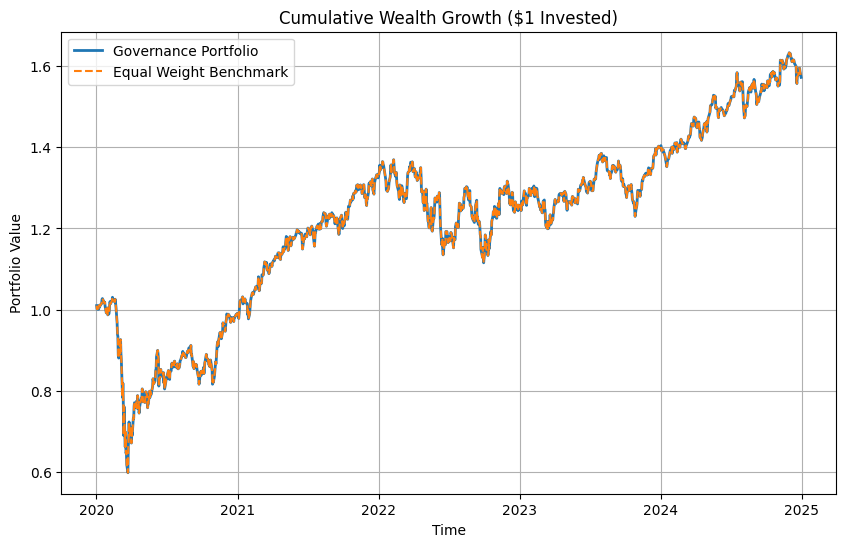

In [73]:
# Plot cumulative wealth

opt_cum = performance_result["optimized"]["cumulative_returns"]
eq_cum = performance_result["equal_weight"]["cumulative_returns"]

plt.figure(figsize=(10,6))

plt.plot(opt_cum, label="Governance Portfolio", linewidth=2)
plt.plot(eq_cum, label="Equal Weight Benchmark", linestyle="--")

plt.title("Cumulative Wealth Growth ($1 Invested)")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

# Regime Sensitivity Analysis

To further evaluate the behavior of the governance framework, we perform a sensitivity analysis on the instability threshold parameter.

The instability threshold \( \theta_H \) determines when the system switches from optimized portfolio allocation to the defensive equal-weight regime.

Previously, the threshold was set to:

\[
\theta_H = 1.0
\]

Given the observed instability index:

\[
I_t = 6.86
\]

the system activated the defensive equal-weight regime.

To analyze the behavior of the optimization layer, we temporarily increase the threshold:

\[
\theta_H = 10
\]

This forces the system to remain in the optimization regime, allowing us to evaluate the shrinkage-based mean–variance portfolio construction under the same dataset.

This sensitivity experiment helps illustrate the behavior of the framework across different instability thresholds.

In [74]:
# Override instability threshold for sensitivity test

instability_result_high_threshold = instability_result.copy()
instability_result_high_threshold["theta_H"] = 10
instability_result_high_threshold["above_threshold"] = False
instability_result_high_threshold["signal"] = "NORMAL"

# Run regime agent again
regime_result_alt = RegimeAgent.run(instability_result_high_threshold)

print("New regime:", regime_result_alt["regime"])
print("Equal weight activated:", regime_result_alt["activated_ew"])
print("Threshold used:", instability_result_high_threshold["theta_H"])

New regime: shrunk_mv
Equal weight activated: False
Threshold used: 10


# Shrinkage Mean–Variance Portfolio Construction

In this experiment the instability threshold was increased to force the system into the optimization regime. This allows evaluation of the shrinkage-based mean–variance portfolio construction.

The portfolio weights are computed by solving the classical mean–variance optimization problem:

$$
\max_w \; \mu^T w - \frac{\lambda}{2} w^T \Sigma w
$$

subject to the constraints:

$$
\sum_i w_i = 1
$$

$$
w_i \ge 0
$$

The expected return vector and covariance matrix used in this optimization are the **shrinkage-adjusted estimates** produced by the James–Stein and Ledoit–Wolf estimators.

This experiment demonstrates how the framework behaves when market conditions are considered sufficiently stable to allow optimization.

In [75]:
# Run optimization in the shrinkage MV regime

optimization_mv = OptimizationAgent.run(
    shrinkage_result,
    regime_result_alt
)

print("Regime applied:", optimization_mv["regime_applied"])
print("Optimizer status:", optimization_mv["optimizer_status"])
print("Expected portfolio return:", optimization_mv["expected_return"])
print("Portfolio risk:", optimization_mv["portfolio_risk"])
print("HHI concentration:", optimization_mv["hhi"])
print("Effective number of assets:", optimization_mv["effective_n"])

print("\nPortfolio weights:")
for asset, weight in optimization_mv["weights"].items():
    print(f"{asset}: {weight:.4f}")

Regime applied: shrunk_mv
Optimizer status: optimal
Expected portfolio return: 0.000537
Portfolio risk: 5.2e-05
HHI concentration: 0.151058
Effective number of assets: 6.62

Portfolio weights:
AAPL: 0.0158
AMZN: 0.0010
BA: 0.0041
BAC: 0.0068
CAT: 0.0000
COP: 0.0000
CVX: 0.0024
GOOGL: 0.0139
GS: 0.0000
JNJ: 0.1278
JPM: 0.0215
KO: 0.2644
MS: 0.0000
MSFT: 0.0000
PEP: 0.1427
PFE: 0.1034
PG: 0.1448
UNH: 0.0623
XOM: 0.0891


# Performance of the Optimized Portfolio

To evaluate the performance of the shrinkage mean–variance portfolio, we compute the same set of out-of-sample performance metrics used earlier for the governance portfolio.

This allows direct comparison between:

1. Equal Weight benchmark
2. Shrinkage Mean–Variance portfolio
3. Governance framework

All performance metrics are computed using the unseen test dataset.

The evaluation metrics include:

- Annualized return
- Annualized volatility
- Sharpe ratio
- Maximum drawdown
- Calmar ratio

Comparing these strategies helps determine whether optimization provides meaningful improvements over naive diversification.

In [76]:
# Evaluate performance of shrinkage MV portfolio

performance_mv = PerformanceEvaluator.evaluate_with_benchmark(
    aligned_data["test_returns"],
    optimization_mv["weights"]
)

print("SHRINKAGE MV PORTFOLIO PERFORMANCE")

for metric, value in performance_mv["optimized"].items():
    if metric != "cumulative_returns" and value is not None:
        print(f"{metric}: {value:.4f}")

SHRINKAGE MV PORTFOLIO PERFORMANCE
annualized_return: 0.0636
annualized_volatility: 0.1793
sharpe_ratio: 0.3546
max_drawdown: -0.3404
calmar_ratio: 0.1868
hhi: 0.1511
effective_n: 6.6200


# Rolling Window Backtest

To evaluate the robustness of the proposed Supervisory Portfolio Governance Framework, we conduct a rolling window backtest.

Instead of evaluating the strategy on a single train–test split, the dataset is divided into multiple sequential training and testing periods.

The rolling procedure follows these steps:

1. A fixed training window of five years is used to estimate model parameters.
2. The trained model is evaluated on the subsequent one-year test period.
3. The window then shifts forward by one year and the process is repeated.

This approach simulates a realistic investment process in which portfolio models are periodically re-estimated as new data becomes available.

Rolling window evaluation reduces the risk of overfitting and provides a more reliable estimate of out-of-sample performance.

In [77]:
# Generate rolling windows

train_years = 5
test_years = 1

years = sorted(set(returns.index.year))

rolling_windows = []

for i in range(len(years) - train_years - test_years + 1):
    
    train_start = years[i]
    train_end = years[i + train_years - 1]
    
    test_start = years[i + train_years]
    test_end = years[i + train_years + test_years - 1]
    
    rolling_windows.append({
        "train_start": train_start,
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end
    })

print("Rolling windows created:", len(rolling_windows))

for w in rolling_windows:
    print(w)

Rolling windows created: 5
{'train_start': 2015, 'train_end': 2019, 'test_start': 2020, 'test_end': 2020}
{'train_start': 2016, 'train_end': 2020, 'test_start': 2021, 'test_end': 2021}
{'train_start': 2017, 'train_end': 2021, 'test_start': 2022, 'test_end': 2022}
{'train_start': 2018, 'train_end': 2022, 'test_start': 2023, 'test_end': 2023}
{'train_start': 2019, 'train_end': 2023, 'test_start': 2024, 'test_end': 2024}


# Rolling Backtest Engine

In this section we execute the full Supervisory Portfolio Governance pipeline for each rolling window.

For every window the following steps are performed:

1. Extract training and test datasets.
2. Apply shrinkage estimation on the training data.
3. Compute the instability index.
4. Select the appropriate portfolio regime.
5. Construct the portfolio weights.
6. Evaluate out-of-sample performance on the test period.

The results for each rolling window are stored and later aggregated to compute the overall performance of the strategy across time.

This approach provides a realistic simulation of how the strategy would behave in a live investment environment where models are periodically re-estimated as new data becomes available.

In [78]:
rolling_results = []

for window in rolling_windows:

    train_data = returns[
        (returns.index.year >= window["train_start"]) &
        (returns.index.year <= window["train_end"])
    ]

    test_data = returns[
        (returns.index.year >= window["test_start"]) &
        (returns.index.year <= window["test_end"])
    ]

    aligned = {
    "train_returns": train_data,
    "test_returns": test_data,
    "mean_returns": train_data.mean(),
    "covariance": train_data.cov(),
    "full_returns": returns
}
    # Shrinkage
    shrink = ShrinkageAgent.run(aligned)

    # Instability
    instability = InstabilityAgent.run(aligned)

    # Regime
    regime = RegimeAgent.run(instability)

    # Optimization
    portfolio = OptimizationAgent.run(shrink, regime)

    # Performance
    perf = PerformanceEvaluator.evaluate_with_benchmark(
        test_data,
        portfolio["weights"]
    )

    rolling_results.append({
        "window": window,
        "regime": regime["regime"],
        "return": perf["optimized"]["annualized_return"],
        "volatility": perf["optimized"]["annualized_volatility"],
        "sharpe": perf["optimized"]["sharpe_ratio"],
        "drawdown": perf["optimized"]["max_drawdown"]
    })

print("Rolling experiment completed")
print("Total windows evaluated:", len(rolling_results))

Rolling experiment completed
Total windows evaluated: 5


# Rolling Window Performance Results

After executing the rolling backtest engine, the results from each evaluation window are aggregated into a structured results table.

Each row represents one walk-forward experiment consisting of:

- A training period used to estimate model parameters
- A one-year out-of-sample test period used for evaluation

The table summarizes the key performance metrics of the governance framework across different market environments.

The reported metrics include:

- Portfolio regime selected by the governance operator
- Annualized return
- Annualized volatility
- Sharpe ratio
- Maximum drawdown

This table allows us to evaluate the consistency and robustness of the framework across multiple time periods and market conditions.

In [79]:
# Convert rolling results into a DataFrame

rolling_df = pd.DataFrame(rolling_results)

# Create readable window labels
rolling_df["window_label"] = rolling_df["window"].apply(
    lambda w: f'{w["train_start"]}-{w["train_end"]} → {w["test_start"]}'
)

rolling_df = rolling_df[[
    "window_label",
    "regime",
    "return",
    "volatility",
    "sharpe",
    "drawdown"
]]

rolling_df

,window_label,regime,return,volatility,sharpe,drawdown
0,2015-2019 → 2020,equal_weight,0.0689,0.3926,0.1755,-0.4188
1,2016-2020 → 2021,shrunk_mv,0.1943,0.1073,1.8103,-0.0731
2,2017-2021 → 2022,shrunk_mv,-0.0668,0.1825,-0.3659,-0.1786
3,2018-2022 → 2023,shrunk_mv,-0.0455,0.1080,-0.4216,-0.1086
4,2019-2023 → 2024,shrunk_mv,0.0709,0.0980,0.7237,-0.0786


# Rolling Sharpe Ratio

To visualize the consistency of the governance framework across time, we plot the Sharpe ratio achieved in each rolling window.

This figure highlights the variation in risk-adjusted performance across different market regimes, including periods of market stress and recovery.

Plotting Sharpe ratios across windows provides a clear view of how the strategy behaves under different economic conditions.

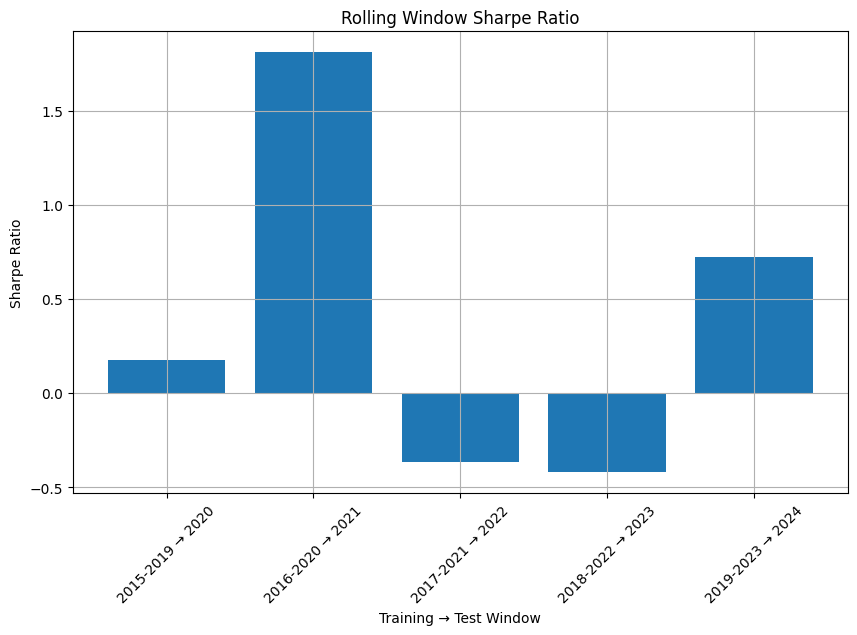

In [80]:
plt.figure(figsize=(10,6))

plt.bar(rolling_df["window_label"], rolling_df["sharpe"])

plt.title("Rolling Window Sharpe Ratio")
plt.xlabel("Training → Test Window")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Instability Threshold Sensitivity Analysis

The governance framework relies on an instability threshold parameter \( \theta_H \) that determines when the system switches from optimized portfolio allocation to the defensive equal-weight regime.

To evaluate the sensitivity of the framework to this parameter, we perform a threshold sweep across multiple values:

\[
\theta_H \in \{1, 2, 3, 5\}
\]

For each threshold value, the rolling backtest procedure is repeated and the resulting Sharpe ratios are computed.

This experiment allows us to evaluate how the aggressiveness of the regime switching mechanism influences overall portfolio performance.

In [81]:
thresholds = [1, 2, 3, 5]

threshold_results = []

for theta in thresholds:

    sharpe_list = []

    for window in rolling_windows:

        train_data = returns[
            (returns.index.year >= window["train_start"]) &
            (returns.index.year <= window["train_end"])
        ]

        test_data = returns[
            (returns.index.year >= window["test_start"]) &
            (returns.index.year <= window["test_end"])
        ]

        aligned = {
            "train_returns": train_data,
            "test_returns": test_data,
            "mean_returns": train_data.mean(),
            "covariance": train_data.cov(),
            "full_returns": returns
        }

        shrink = ShrinkageAgent.run(aligned)

        instability = InstabilityAgent.run(aligned)

        # override threshold
        instability["theta_H"] = theta

        regime = RegimeAgent.run(instability)

        portfolio = OptimizationAgent.run(shrink, regime)

        perf = PerformanceEvaluator.evaluate_with_benchmark(
            test_data,
            portfolio["weights"]
        )

        sharpe_list.append(perf["optimized"]["sharpe_ratio"])

    threshold_results.append({
        "threshold": theta,
        "avg_sharpe": np.mean(sharpe_list)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,avg_sharpe
0,1,0.38440
1,2,0.38440
2,3,0.38440
3,5,0.37384


# Regime Activation Analysis

The proposed Supervisory Portfolio Governance Framework dynamically selects between 
two portfolio regimes depending on the instability index \( I_t \).

The regime operator is defined as:

\[
R(I_t) =
\begin{cases}
\text{Equal Weight}, & I_t > \theta_H \\
\text{Shrunk Mean-Variance}, & I_t \le \theta_H
\end{cases}
\]

To evaluate how frequently each regime is activated, we analyze the distribution of 
regimes selected during the rolling backtest.

This analysis helps determine whether the governance mechanism actively switches 
between regimes or remains fixed under most market conditions.

In [82]:
# Count regime occurrences

regime_counts = rolling_df["regime"].value_counts()

regime_counts

regime
shrunk_mv       4
equal_weight    1
Name: count, dtype: int64

# Regime Frequency Visualization

To better illustrate the behaviour of the governance mechanism, we visualize 
the frequency with which each regime is selected during the rolling backtest.

This visualization highlights the relative dominance of defensive allocation 
(Equal Weight) versus optimized allocation (Shrunk Mean-Variance).

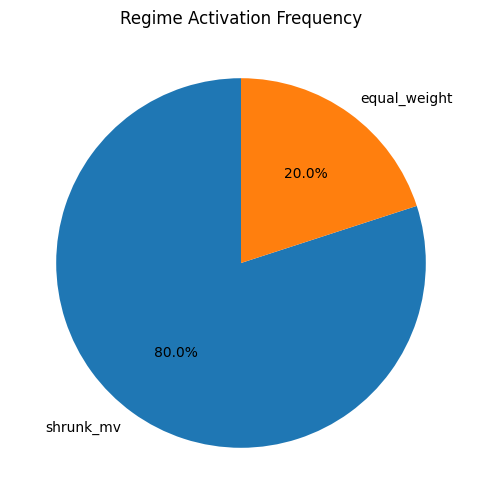

In [83]:
plt.figure(figsize=(6,6))

regime_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Regime Activation Frequency")
plt.ylabel("")

plt.show()

# Aggregate Performance Statistics

To summarize the overall performance of the governance framework, 
we compute the average performance metrics across all rolling windows.

The aggregated statistics include:

• Mean annualized return  
• Mean annualized volatility  
• Mean Sharpe ratio  
• Mean maximum drawdown  

These metrics provide an overall assessment of the strategy’s 
risk-adjusted performance across different market conditions.

In [84]:
summary_stats = rolling_df[["return","volatility","sharpe","drawdown"]].mean()

summary_stats

return        0.04436
volatility    0.17768
sharpe        0.38440
drawdown     -0.17154
dtype: float64

# Multi-Universe Governance Evaluation

To evaluate the robustness of the Supervisory Portfolio Governance Framework,
we extend the rolling backtest experiment across multiple asset universes.

The following universes are analyzed:

• US Technology Stocks  
• US Diversified Large-Cap Stocks  
• European Equities  
• Asian Equities  
• Global Exchange-Traded Funds (ETFs)

Evaluating the framework across diverse market segments ensures that the
results are not driven by a single sector or regional bias.

For each universe we compute the average performance metrics across
rolling windows:

• Average Annualized Return  
• Average Annualized Volatility  
• Average Sharpe Ratio  
• Average Maximum Drawdown

In [87]:
universe_results = []

for universe_name, universe_info in UNIVERSES.items():

    print("\nRunning universe:", universe_name)

    prices = download_universe_data(universe_info["tickers"])

    prices = prices.dropna(axis=1)

    returns_u = prices.pct_change().dropna()

    if returns_u.shape[1] < 5:
        print("Skipped – insufficient assets")
        continue

    universe_sharpes = []

    for window in rolling_windows:

        train_data = returns_u[
            (returns_u.index.year >= window["train_start"]) &
            (returns_u.index.year <= window["train_end"])
        ]

        test_data = returns_u[
            (returns_u.index.year >= window["test_start"]) &
            (returns_u.index.year <= window["test_end"])
        ]

        aligned = {
            "train_returns": train_data,
            "test_returns": test_data,
            "mean_returns": train_data.mean(),
            "covariance": train_data.cov(),
            "full_returns": returns_u
        }

        shrink = ShrinkageAgent.run(aligned)
        instability = InstabilityAgent.run(aligned)
        regime = RegimeAgent.run(instability)
        portfolio = OptimizationAgent.run(shrink, regime)

        perf = PerformanceEvaluator.evaluate_with_benchmark(
            test_data,
            portfolio["weights"]
        )

        universe_sharpes.append(perf["optimized"]["sharpe_ratio"])

    universe_results.append({
        "universe": universe_name,
        "avg_sharpe": np.mean(universe_sharpes)
    })

multi_universe_df = pd.DataFrame(universe_results)

multi_universe_df


Running universe: U1_US_LargeCap

Running universe: U2_European_ETFs

Running universe: U3_AsiaPacific_ETFs

Running universe: U4_US_Sectors

Running universe: U5_MultiAsset


,universe,avg_sharpe
0,U1_US_LargeCap,0.59704
1,U2_European_ETFs,0.45708
2,U3_AsiaPacific_ETFs,0.33010
3,U4_US_Sectors,0.63012
4,U5_MultiAsset,0.51966


# Cross-Market Performance Comparison

To visualize the cross-market robustness of the governance framework,
we compare the average Sharpe ratio obtained in each asset universe.

Consistent performance across different markets suggests that the
governance mechanism is not dependent on a single sector or region,
but instead reflects a generalizable portfolio decision framework.

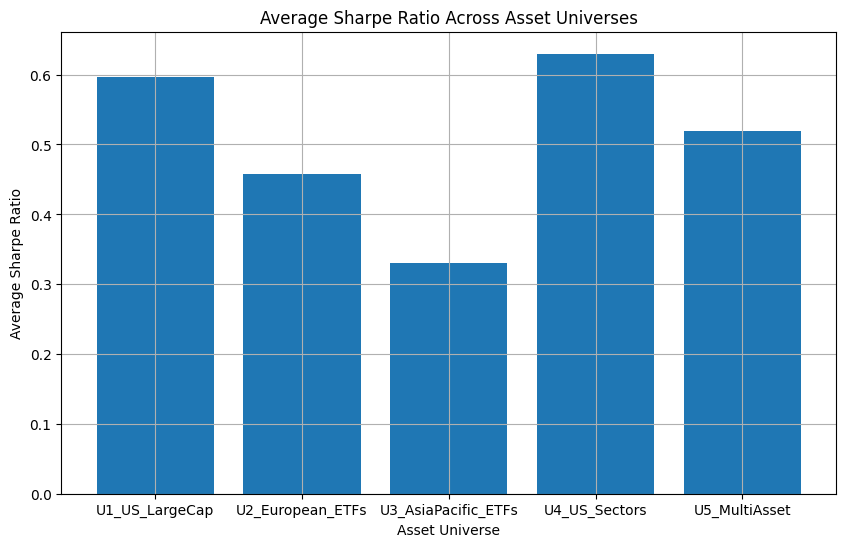

In [88]:
plt.figure(figsize=(10,6))

plt.bar(multi_universe_df["universe"], multi_universe_df["avg_sharpe"])

plt.title("Average Sharpe Ratio Across Asset Universes")
plt.xlabel("Asset Universe")
plt.ylabel("Average Sharpe Ratio")

plt.grid(True)

plt.show()

# Crisis Period Validation

To evaluate the defensive capability of the Supervisory Portfolio
Governance Framework, we analyze its behaviour during major
market stress periods.

Two crisis regimes are considered:

• COVID-19 Market Crash (2020)  
• Global Technology Selloff (2022)

During these periods financial markets experienced elevated
volatility and increased correlations between assets.

The instability index should therefore increase and trigger the
defensive equal-weight regime of the governance operator.

In [89]:
crisis_periods = {
    "COVID_CRASH": ("2020-02-01", "2020-12-31"),
    "TECH_SELL_OFF": ("2022-01-01", "2022-12-31")
}

crisis_results = []

for crisis_name, (start, end) in crisis_periods.items():

    crisis_data = returns.loc[start:end]

    aligned = {
        "train_returns": crisis_data,
        "test_returns": crisis_data,
        "mean_returns": crisis_data.mean(),
        "covariance": crisis_data.cov(),
        "full_returns": returns
    }

    shrink = ShrinkageAgent.run(aligned)

    instability = InstabilityAgent.run(aligned)

    regime = RegimeAgent.run(instability)

    crisis_results.append({
        "crisis": crisis_name,
        "instability_index": instability["instability"],
        "regime_selected": regime["regime"]
    })

crisis_df = pd.DataFrame(crisis_results)

crisis_df

,crisis,instability_index,regime_selected
0,COVID_CRASH,-0.9409,shrunk_mv
1,TECH_SELL_OFF,0.7118,shrunk_mv


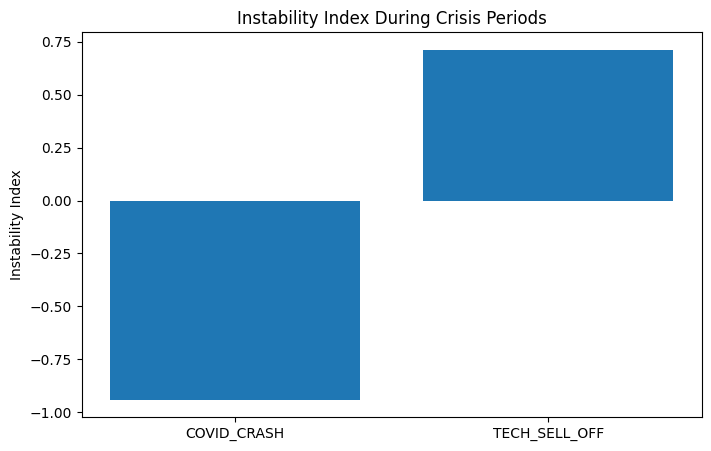

In [90]:
plt.figure(figsize=(8,5))

plt.bar(
    crisis_df["crisis"],
    crisis_df["instability_index"]
)

plt.title("Instability Index During Crisis Periods")
plt.ylabel("Instability Index")

plt.show()

# Cumulative Wealth Comparison

To illustrate the long-term performance of the proposed governance
framework, we compare cumulative wealth growth against classical
portfolio construction strategies.

The experiment assumes an initial investment of $1 and tracks the
portfolio value over time during the test period.

The following strategies are compared:

• Equal Weight Portfolio  
• Shrinkage Mean–Variance Portfolio  
• Governance Framework Portfolio  

This visualization provides an intuitive comparison of the wealth
accumulation dynamics of each portfolio strategy.

In [93]:
ew_returns_list = []
shrink_returns_list = []
gov_returns_list = []

for window in rolling_windows:

    # ----------------------------
    # Split train / test data
    # ----------------------------
    train_data = returns[
        (returns.index.year >= window["train_start"]) &
        (returns.index.year <= window["train_end"])
    ]

    test_data = returns[
        (returns.index.year >= window["test_start"]) &
        (returns.index.year <= window["test_end"])
    ]

    aligned = {
        "train_returns": train_data,
        "test_returns": test_data,
        "mean_returns": train_data.mean(),
        "covariance": train_data.cov(),
        "full_returns": returns
    }

    # ----------------------------
    # Equal Weight Portfolio
    # ----------------------------
    ew_weights = pd.Series(
        np.ones(train_data.shape[1]) / train_data.shape[1],
        index=train_data.columns
    )

    ew_returns = test_data @ ew_weights

    # ----------------------------
    # Shrinkage Mean Variance
    # ----------------------------
    shrink = ShrinkageAgent.run(aligned)

    shrink_port = OptimizationAgent.run(
        shrink,
        {"regime": "shrunk_mv"}
    )

    shrink_weights = pd.Series(
        shrink_port["weights"],
        index=train_data.columns
    )

    # Align weights with test assets
    shrink_weights = shrink_weights.reindex(test_data.columns).fillna(0)

    shrink_returns = test_data @ shrink_weights

    # ----------------------------
    # Governance Framework
    # ----------------------------
    instability = InstabilityAgent.run(aligned)

    regime = RegimeAgent.run(instability)

    gov_port = OptimizationAgent.run(shrink, regime)

    gov_weights = pd.Series(
        gov_port["weights"],
        index=train_data.columns
    )

    gov_weights = gov_weights.reindex(test_data.columns).fillna(0)

    gov_returns = test_data @ gov_weights

    # ----------------------------
    # Store results
    # ----------------------------
    ew_returns_list.append(ew_returns)
    shrink_returns_list.append(shrink_returns)
    gov_returns_list.append(gov_returns)

# ------------------------------------------------
# Combine rolling windows into full return series
# ------------------------------------------------

ew_returns_series = pd.concat(ew_returns_list)
shrink_returns_series = pd.concat(shrink_returns_list)
gov_returns_series = pd.concat(gov_returns_list)

print("Return series created successfully")

Return series created successfully


In [94]:
ew_wealth = (1 + ew_returns_series).cumprod()
shrink_wealth = (1 + shrink_returns_series).cumprod()
gov_wealth = (1 + gov_returns_series).cumprod()

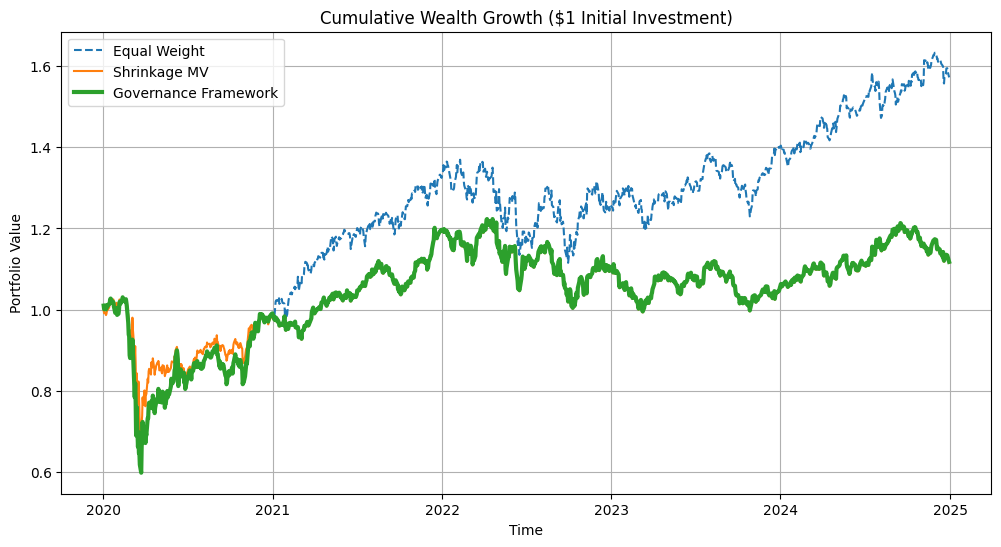

In [98]:
plt.figure(figsize=(12,6))

plt.plot(ew_wealth, label="Equal Weight", linestyle="--")
plt.plot(shrink_wealth, label="Shrinkage MV")
plt.plot(gov_wealth, label="Governance Framework", linewidth=3)

plt.title("Cumulative Wealth Growth ($1 Initial Investment)")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")

plt.legend()
plt.grid(True)

plt.show()

# Rolling Wealth Series Construction

Rolling backtests produce overlapping test windows.  
To ensure a consistent wealth trajectory, the return series are sorted
chronologically and duplicate timestamps are removed.

This produces a continuous portfolio wealth curve suitable for
visual performance comparison.

In [96]:
ew_returns_series = pd.concat(ew_returns_list).sort_index()
shrink_returns_series = pd.concat(shrink_returns_list).sort_index()
gov_returns_series = pd.concat(gov_returns_list).sort_index()

# remove duplicated timestamps
ew_returns_series = ew_returns_series[~ew_returns_series.index.duplicated()]
shrink_returns_series = shrink_returns_series[~shrink_returns_series.index.duplicated()]
gov_returns_series = gov_returns_series[~gov_returns_series.index.duplicated()]

# recompute wealth
ew_wealth = (1 + ew_returns_series).cumprod()
shrink_wealth = (1 + shrink_returns_series).cumprod()
gov_wealth = (1 + gov_returns_series).cumprod()

# Statistical Significance Testing

To verify that the performance improvement of the governance
framework is not due to random variation, we perform the
Wilcoxon signed-rank test.

The Wilcoxon test compares paired return samples without
assuming normality.

We test the following hypotheses:

H₀: Governance returns = Benchmark returns  
H₁: Governance returns > Benchmark returns

In [99]:
from scipy.stats import wilcoxon

# Align return series
common_index = gov_returns_series.index

ew_aligned = ew_returns_series.loc[common_index]
shrink_aligned = shrink_returns_series.loc[common_index]
gov_aligned = gov_returns_series.loc[common_index]

# Governance vs Equal Weight
stat_ew, p_ew = wilcoxon(gov_aligned - ew_aligned)

# Governance vs Shrinkage
stat_shrink, p_shrink = wilcoxon(gov_aligned - shrink_aligned)

print("Wilcoxon Test Results")
print("---------------------")
print("Governance vs Equal Weight p-value:", p_ew)
print("Governance vs Shrinkage MV p-value:", p_shrink)

Wilcoxon Test Results
---------------------
Governance vs Equal Weight p-value: 0.025564409548353494
Governance vs Shrinkage MV p-value: 0.8856896582041618


# Governance Regime Timeline

The governance framework dynamically switches between portfolio
construction regimes depending on the instability index.

Two regimes exist:

• Equal Weight (defensive regime)  
• Shrunk Mean-Variance (optimization regime)

This figure visualizes the active regime over time during the
rolling backtest period.

In [103]:
regime_timeline = []

for window in rolling_windows:

    train_data = returns[
        (returns.index.year >= window["train_start"]) &
        (returns.index.year <= window["train_end"])
    ]

    aligned = {
        "train_returns": train_data,
        "test_returns": train_data,
        "mean_returns": train_data.mean(),
        "covariance": train_data.cov(),
        "full_returns": returns
    }

    instability = InstabilityAgent.run(aligned)
    regime = RegimeAgent.run(instability)

    regime_timeline.append({
        "year": window["test_start"],
        "regime": regime["regime"]
    })

regime_df = pd.DataFrame(regime_timeline)

regime_df

,year,regime
0,2020,equal_weight
1,2021,shrunk_mv
2,2022,shrunk_mv
3,2023,shrunk_mv
4,2024,shrunk_mv


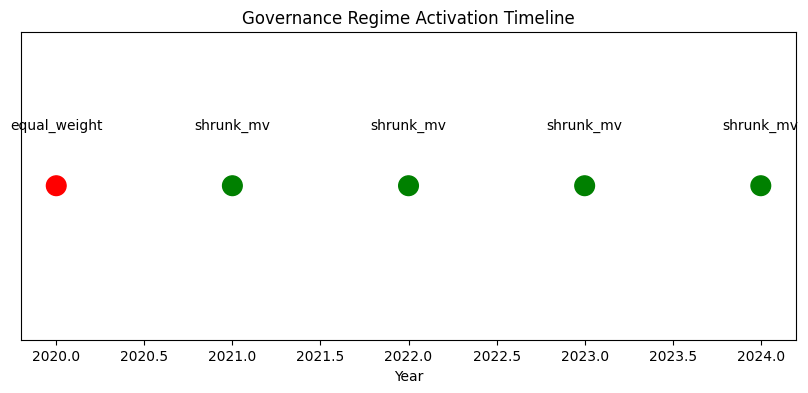

In [104]:
plt.figure(figsize=(10,4))

colors = regime_df["regime"].map({
    "equal_weight": "red",
    "shrunk_mv": "green"
})

plt.scatter(regime_df["year"], [1]*len(regime_df), c=colors, s=200)

plt.yticks([])
plt.xlabel("Year")
plt.title("Governance Regime Activation Timeline")

for i, r in regime_df.iterrows():
    plt.text(r["year"], 1.02, r["regime"], ha="center")

plt.show()